In [1]:
import json
import os
import pandas as pd

In [5]:
result_files = os.listdir('../experiments/testing/final_results')
result_files = [col for col in result_files if '.json' in col]
result_files

['1169_13.json',
 '1461_13.json',
 '1464_13.json',
 '1468_13.json',
 '1475_13.json',
 '1590_13.json',
 '1596_13.json',
 '188_13.json',
 '23512_13.json',
 '23_13.json',
 '31_13.json',
 '40668_13.json',
 '40670_13.json',
 '40701_13.json',
 '40975_13.json',
 '40981_13.json',
 '40996_13.json',
 '41138_13.json',
 '41142_13.json',
 '41147_13.json',
 '41156_13.json',
 '41157_13.json',
 '41158_13.json',
 '41159_13.json',
 '41163_13.json',
 '41164_13.json',
 '41167_13.json',
 '41169_13.json',
 '4134_13.json',
 '4135_13.json',
 '42733_13.json',
 '42769_13.json',
 '4538_13.json',
 '4541_13.json',
 '54_13.json']

In [9]:
results_path = '../experiments/testing/final_results'
exp_records = []
for exp_file in result_files:
    exp_id = exp_file.split('.')[0]
    with open(os.path.join(results_path, exp_file), 'r') as f:
        data = json.load(f)
        exp_records.append(data)

exp_df = pd.DataFrame(exp_records)
exp_df.to_csv(os.path.join(results_path, 'summary', 'all_experiments.csv'), index=False)


In [10]:
display(exp_df.head())

,exp_id,data_id,seed,n_rows,n_features,hgb_accuracy,hgb_training_time_sec,mlp_training_time,mlp_train_acc,mlp_train_loss,...,ebe_benefit_est,ebe_cost_est,ebe_top_forecast_val_acc,ebe_top_forecast_CI_high,ebe_val_acc,ebe_test_acc,ebe_surpassed_val_baseline,ebe_surpassed_test_baseline,ebe_time_vs_hist_ratio,ebe_time_vs_mlp_ratio
0,1169_13,1169,13,431506,7,0.661197,0.999577,30.372907,0.647588,0.626072,...,0.020000,13.779446,0.651541,0.725599,0.000000,0.000000,False,False,60.878039,2.003505
1,1461_13,1461,13,36168,16,0.905452,0.219122,9.939396,0.920150,0.189768,...,0.085244,6.793967,0.999453,1.000000,0.000000,0.000000,False,False,276.747640,6.101129
2,1464_13,1464,13,598,4,0.753333,0.062007,0.137540,0.811037,0.447788,...,0.043300,0.000000,0.825000,NaN,0.808333,0.800000,True,True,9.569033,4.314038
3,1468_13,1468,13,864,856,0.814815,10.954694,0.595086,1.000000,0.003872,...,0.050086,0.780005,0.996775,1.000000,0.000000,0.000000,False,False,5.497614,101.203265
4,1475_13,1475,13,4894,51,0.613562,0.953100,1.735079,0.656723,0.941281,...,0.348535,0.615249,0.953235,1.000000,0.426966,0.419935,False,False,10.733513,5.896053


In [11]:
exp_df.head().to_csv(os.path.join(results_path, 'summary', 'all_experiments_head.csv'), index=False)

In [12]:

# --- core decision stats ---
n_total = len(exp_df)
n_worthy = exp_df["ebe_decision"].sum()
prop_worthy = n_worthy / n_total

n_val_surpass = exp_df["ebe_surpassed_val_baseline"].sum()
n_test_surpass = exp_df["ebe_surpassed_test_baseline"].sum()

print(f"Total datasets: {n_total}")
print(f"Neural-worthy (EBE decided True): {n_worthy} ({prop_worthy:.1%})")
print(f"Surpassed validation baseline: {n_val_surpass} ({n_val_surpass/n_total:.1%})")
print(f"Surpassed test baseline: {n_test_surpass} ({n_test_surpass/n_total:.1%})")


Total datasets: 35
Neural-worthy (EBE decided True): 17 (48.6%)
Surpassed validation baseline: 3 (8.6%)
Surpassed test baseline: 2 (5.7%)


C:\Users\v-rasantiago\AppData\Local\Temp\ipykernel_11764\2538909692.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="ebe_decision", data=exp_df, palette="coolwarm")


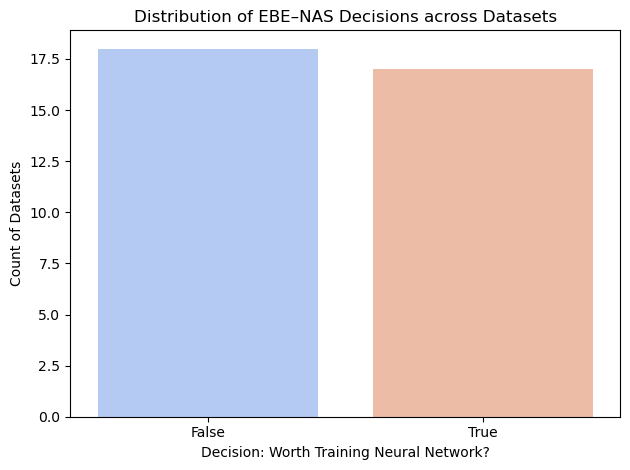

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="ebe_decision", data=exp_df, palette="coolwarm")
plt.title("Distribution of EBE–NAS Decisions across Datasets")
plt.xlabel("Decision: Worth Training Neural Network?")
plt.ylabel("Count of Datasets")
plt.tight_layout()
plt.savefig("../analysis_outputs/decision_distribution.png", dpi=300)


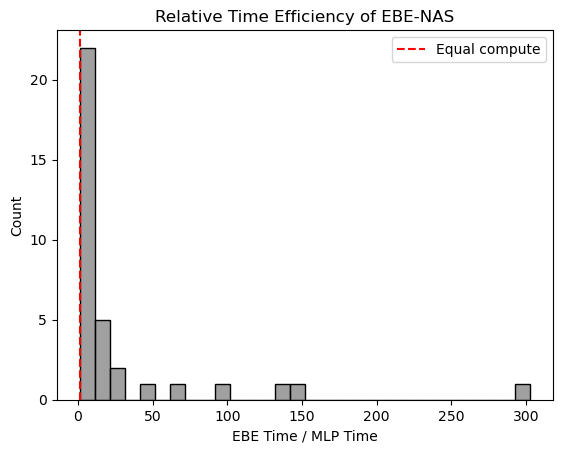

In [17]:
sns.histplot(exp_df["ebe_time_vs_mlp_ratio"], bins=30, color="gray")
plt.axvline(1, color="red", linestyle="--", label="Equal compute")
plt.legend()
plt.xlabel("EBE Time / MLP Time")
plt.title("Relative Time Efficiency of EBE-NAS")
plt.savefig("../analysis_outputs/time_efficiency_histogram.png", dpi=300)


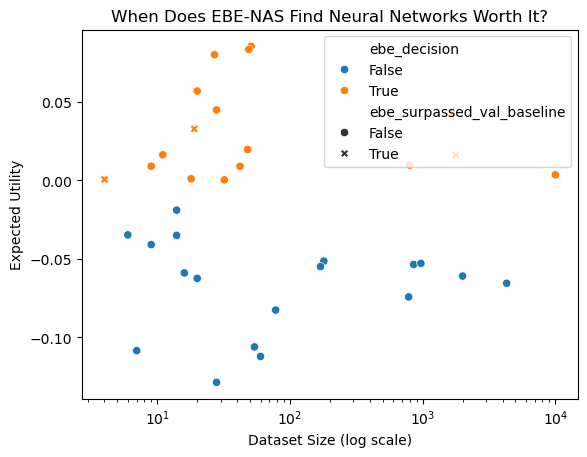

In [21]:
sns.scatterplot(
    x="n_features", y="ebe_expected_utility",
    hue="ebe_decision", style="ebe_surpassed_val_baseline", data=exp_df
)
plt.xscale("log")
plt.xlabel("Dataset Size (log scale)")
plt.ylabel("Expected Utility")
plt.title("When Does EBE-NAS Find Neural Networks Worth It?")
plt.savefig("../analysis_outputs/utility_vs_dataset_size.png", dpi=300)


In [19]:
summary = {
    "Total Datasets": [len(exp_df)],
    "Neural Worthy": [exp_df["ebe_decision"].sum()],
    "Validation Surpassed": [exp_df["ebe_surpassed_val_baseline"].sum()],
    "Test Surpassed": [exp_df["ebe_surpassed_test_baseline"].sum()],
    "Mean Expected Utility": [exp_df["ebe_expected_utility"].mean()],
    "Mean Probability p": [exp_df["ebe_p_above_goal"].mean()]
}
pd.DataFrame(summary).to_latex("../analysis_outputs/ebe_summary_overview.tex", index=False)
